# Data Mining Assignment 3: Clustering and Anomaly Detection
Daan Thielemans [s0210206]

## Task 1: Data Exploration and Preprocessing

imports

In [25]:
import pandas as pd
import numpy as np
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.feature_extraction import text
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
SEED = 66

datasets

In [26]:
try:
    df_anomalies = pd.read_csv('anomalies.csv')
    df_articles = pd.read_csv('articles.csv')
    df_clusters = pd.read_csv('clusters.csv')
    print("all datasets loaded successfully")
except FileNotFoundError as e:
    print(f"error: {e}")

all datasets loaded successfully


check heads

In [27]:
datasets = {
    "anomalies.csv": df_anomalies,
    "articles.csv": df_articles,
    "clusters.csv": df_clusters
}

for name, df in datasets.items():
    print(f"{name} {df.shape}")
    display(df.head(3))

anomalies.csv (50, 2)


,anomaly,doc_id
0,1,DOC_00734
1,2,DOC_01687
2,3,DOC_00534


articles.csv (2164, 2)


,doc_id,text
0,DOC_00001,"When I first saw this, I thought for a second ..."
1,DOC_00002,The difficulties of a high Isp OTV include: Lo...
2,DOC_00003,"Forwarded from Neal Ausman, Galileo Mission Di..."


clusters.csv (2164, 2)


,doc_id,label
0,DOC_00001,1
1,DOC_00002,6
2,DOC_00003,8


filtering, cleaning and bag-of-words

In [28]:
# setup Lemmatizer
lem = WordNetLemmatizer()
def lemma_tokenizer(doc):
    return [lem.lemmatize(w.lower()) for w in doc.split() if w.isalpha()]

# setup CountVectorizer
cv = CountVectorizer(
    tokenizer=lemma_tokenizer,
    stop_words='english', # removes stop words
    min_df=3, # removes rare terms
    max_df=0.9, # removes frequent terms
    token_pattern=None
)

# fit and transform
bow_matrix = cv.fit_transform(df_articles['text'].fillna(''))
print(f"bag-of-words matrix shape: {bow_matrix.shape}")

# preview single article
ARTICLE_IDX = 1
original_text = df_articles.iloc[ARTICLE_IDX]['text']

# convert that specific row of the matrix to a DataFrame
second_row_df = pd.DataFrame(
    bow_matrix[ARTICLE_IDX].toarray(),
    columns=cv.get_feature_names_out()
)

# filter to only words that appear in this document
active_words = second_row_df.columns[second_row_df.iloc[0] > 0]
word_counts = second_row_df[active_words].T.rename(columns={0: 'Count'})

print(f"ORIGINAL TEXT (article #{ARTICLE_IDX})")
print(f"\"{original_text}\"")

print("BAG-OF-WORDS REPRESENTATION (head)")
display(word_counts.sort_values(by='Count', ascending=False).head())

C:\Users\daant\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


bag-of-words matrix shape: (2164, 5224)
ORIGINAL TEXT (article #1)
"The difficulties of a high Isp OTV include: Long transfer times (radiation damage from VanAllen belts for both the spacecraft and OTV Arcjets or Xenon thrusters require huge amounts of power so you have to have either nuclear power source (messy, dangerous and source of radiation damage) or BIG solar arrays (sensitive to radiation, or heavy) that make attitude control and docking a big pain. If you go solar, you have to replace the arrays every trip, with current technology. Nuclear power sources are strongly restricted by international treaty. Refueling (even for very high Isp like xenon) is still required and] turn out to be a pain. You either have to develop autonomous rendezvous or long range teleoperation to do docking or ( and refueling) . You still can't do much plane change because the deltaV required is so high! The Air Force continues to look at doing things this way though. I suppose they are biding their ti

,Count
power,3
source,3
high,3
nuclear,2
long,2


## Task 2: Clustering

tfidf

In [5]:
# add custom words to remove
stop_words = text.ENGLISH_STOP_WORDS.union(['ha', 'doe', 'u', 'wa', 't', 'c', 'v'])

# use TF-IDF instead of simple CountVectorizer
tfidf = TfidfVectorizer(
    tokenizer=lemma_tokenizer,
    stop_words=list(stop_words),
    min_df=3,
    max_df=0.3, # Lowered slightly to be more aggressive with common words
    token_pattern=None
)

tfidf_matrix = tfidf.fit_transform(df_articles['text'].fillna(''))

# normalize to remove artice length factor
tfidf_norm = normalize(tfidf_matrix)

k-means clustering

In [14]:
CLUSTER_COUNT = 10
RANDOM_INITS = 10
km = KMeans(n_clusters=CLUSTER_COUNT, random_state=SEED, n_init=RANDOM_INITS)

# fit and predict
df_articles['kmeans_clusters'] = km.fit_predict(tfidf_norm)

print(df_articles['kmeans_clusters'].value_counts())

kmeans_clusters
6    883
3    312
1    185
0    180
8    168
9    150
5     92
2     92
4     69
7     33
Name: count, dtype: int64


spectral clustering

In [15]:
# calculate cosine similarity
affinity_matrix = cosine_similarity(tfidf_norm)

# use Spectral Clustering with the 'discretize' label strategy
CLUSTER_COUNT = 10
sc_improved = SpectralClustering(
    n_clusters=CLUSTER_COUNT,
    affinity='precomputed', # tell it we already calculated the similarity
    assign_labels='discretize',
    random_state=SEED
)

# fit and predict
df_articles['spectral_clusters'] = sc_improved.fit_predict(affinity_matrix)

print(df_articles['spectral_clusters'].value_counts())

spectral_clusters
0    919
7    423
3    347
9    291
1     71
6     34
2     34
8     18
5     14
4     13
Name: count, dtype: int64


evaluation

In [8]:
# list to store results
eval_results = []

# models
models = {
    "K-Means": df_articles['kmeans_clusters'],
    "Spectral": df_articles['spectral_clusters']
}

print("--- Clustering Evaluation Metrics ---")

for name, labels in models.items():
    # calculate silhouette score (closer to 1 is better)
    s_score = silhouette_score(tfidf_norm, labels)

    # calculate Calinski-Harabasz index (higher is better)
    ch_score = calinski_harabasz_score(tfidf_norm.toarray(), labels)

    eval_results.append({
        "Model": name,
        "Silhouette Score": round(s_score, 4),
        "Calinski-Harabasz": round(ch_score, 2)
    })

# display as a df for easy reading
df_eval = pd.DataFrame(eval_results)
display(df_eval)

# extract top keywords
def get_top_keywords(labels, n_terms=10):
    # map feature names to a dense average per cluster
    feature_names = tfidf.get_feature_names_out()
    dense_tfidf = tfidf_norm.toarray()

    # get unique labels
    unique_labels = sorted(labels.unique())
    for cluster_id in unique_labels:
        indices = np.where(labels == cluster_id)[0]
        cluster_mean = dense_tfidf[indices].mean(axis=0)
        top_indices = cluster_mean.argsort()[-n_terms:][::-1]
        words = [feature_names[i] for i in top_indices]
        count = len(indices)
        print(f"C{cluster_id} ({count} articles): {', '.join(words)}")

print("-- Method A: K-MEANS --")
get_top_keywords(df_articles['kmeans_clusters'])
print("-- Method B: SPECTRAL --")
get_top_keywords(df_articles['spectral_clusters'])

--- Clustering Evaluation Metrics ---


,Model,Silhouette Score,Calinski-Harabasz
0,K-Means,0.0136,8.84
1,Spectral,0.0129,8.20


-- Method A: K-MEANS --
C0 (180 articles): car, dealer, just, price, like, good, new, drive, speed, engine
C1 (185 articles): looking, thanks, know, need, information, thank, email, program, info, post
C2 (92 articles): msg, food, cause, chinese, people, taste, restaurant, allergic, like, reaction
C3 (312 articles): game, team, player, hockey, play, leaf, win, nhl, year, playoff
C4 (69 articles): shameful, surrender, chastity, gordon, bank, blood, probably, patient, medical, good
C5 (92 articles): file, format, image, program, color, convert, tiff, cview, directory, know
C6 (883 articles): just, like, think, people, know, good, make, time, problem, new
C7 (33 articles): bonus, offer, pickup, fast, deal, sale, listing, cash, discount, promo
C8 (168 articles): space, nasa, launch, lunar, moon, just, station, like, think, cost
C9 (150 articles): graphic, computer, software, video, card, vesa, program, image, mode, book
-- Method B: SPECTRAL --
C0 (919 articles): like, just, space, think, 

graph

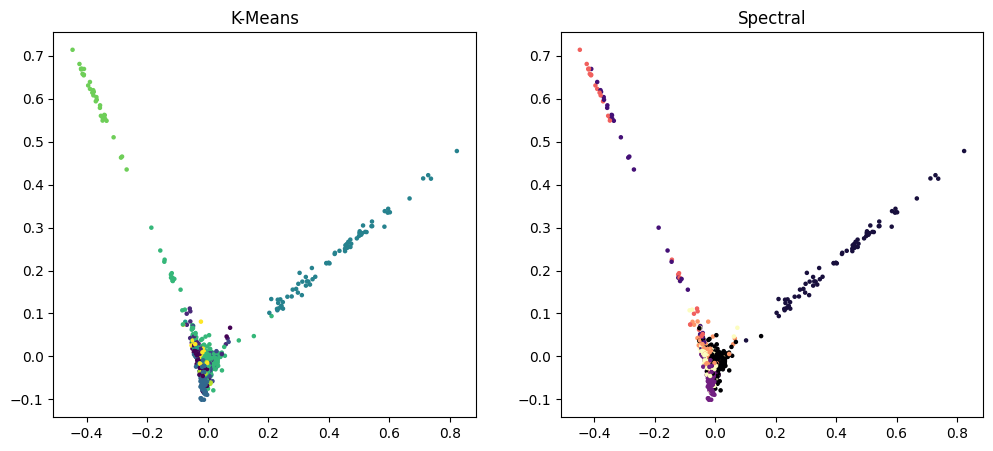

In [20]:
# squash high-dimensional TF-IDF data into 2D points
coords = PCA(n_components=2, random_state=SEED).fit_transform(tfidf_norm.toarray())

# compare the two clustering results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(coords[:, 0], coords[:, 1], c=df_articles['kmeans_clusters'], s=5, cmap='viridis')
axes[0].set_title('K-Means')

axes[1].scatter(coords[:, 0], coords[:, 1], c=df_articles['spectral_clusters'], s=5, cmap='magma')
axes[1].set_title('Spectral')

plt.show()

export

In [9]:
# get clusters
output_df = df_articles[['doc_id', 'kmeans_clusters']].copy()

# formatting for submission
output_df = output_df.rename(columns={'kmeans_clusters': 'label'})
output_df['label'] = output_df['label'].astype(int)

# final save
output_df.to_csv('clusters.csv', index=False)

print("'clusters.csv' filled successfully")
print(f"Total records exported: {len(output_df)}")

'clusters.csv' filled successfully
Total records exported: 2164


## Task 3: Anomaly Detection

identify anomalies

In [10]:
# initialize and fit the model
contamination_rate = 50 / len(df_articles)
iso_forest = IsolationForest(n_estimators=100, contamination=contamination_rate, random_state=SEED)
iso_forest.fit(tfidf_norm)

# get scores and extract the 50 most extreme outliers
df_articles['anomaly_score'] = iso_forest.decision_function(tfidf_norm)
anomalies_df = df_articles.nsmallest(50, 'anomaly_score').copy()

# create the specific format
anomalies_output = pd.DataFrame({
    'anomaly': range(1, 51),
    'doc_id': anomalies_df['doc_id'].values
})

# save to CSV
anomalies_output.to_csv('anomalies.csv', index=False)

print("'anomalies.csv' filled with 50 IDs")
print(anomalies_output.head())

'anomalies.csv' filled with 50 IDs
   anomaly     doc_id
0        1  DOC_00734
1        2  DOC_01687
2        3  DOC_00534
3        4  DOC_01389
4        5  DOC_00847


graph

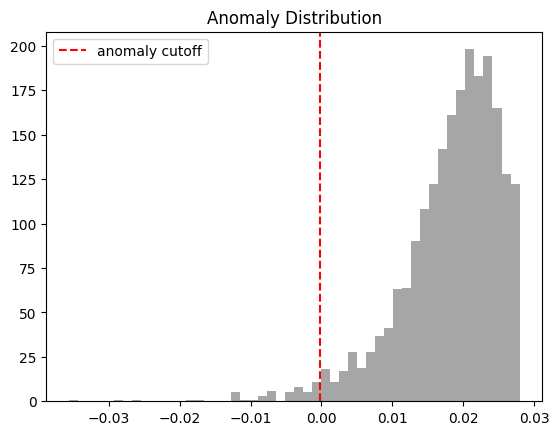

In [23]:
# plot the histogram of all scores
plt.hist(df_articles['anomaly_score'], bins=50, color='gray', alpha=0.7)

# draw a line at the threshold of the 50th most anomalous file
threshold = anomalies_df['anomaly_score'].max()
plt.axvline(threshold, color='red', linestyle='--', label='anomaly cutoff')

plt.title('Anomaly Distribution')
plt.legend()
plt.show()